In [1]:
from helper import *

I moved classes and functions from the 2X training notebook to the `helper.py` not to rewrite the same code

In [2]:
HR_train_paths = sorted(glob.glob("../data/DIV2K_train_HR/*.png"))
X2_train_paths = sorted(glob.glob("../data/DIV2K_train_LR_bicubic/X2/*.png"))
X4_train_paths = sorted(glob.glob("../data/DIV2K_train_LR_bicubic/X4/*.png"))
X8_train_paths = sorted(glob.glob("../data/DIV2K_train_LR_bicubic/X8/*.png"))
X16_train_paths = sorted(glob.glob("../data/DIV2K_train_LR_bicubic/X16/*.png"))
X32_train_paths = sorted(glob.glob("../data/DIV2K_train_LR_bicubic/X32/*.png"))
X64_train_paths = sorted(glob.glob("../data/DIV2K_train_LR_bicubic/X64/*.png"))

HR_valid_paths = sorted(glob.glob("../data/DIV2K_valid_HR/*.png"))
X2_valid_paths = sorted(glob.glob("../data/DIV2K_valid_LR_bicubic/X2/*.png"))
X4_valid_paths = sorted(glob.glob("../data/DIV2K_valid_LR_bicubic/X4/*.png"))
X8_valid_paths = sorted(glob.glob("../data/DIV2K_valid_LR_bicubic/X8/*.png"))
X16_valid_paths = sorted(glob.glob("../data/DIV2K_valid_LR_bicubic/X16/*.png"))
X32_valid_paths = sorted(glob.glob("../data/DIV2K_valid_LR_bicubic/X32/*.png"))
X64_valid_paths = sorted(glob.glob("../data/DIV2K_valid_LR_bicubic/X64/*.png"))

## X4 Scaling

In [3]:
checkpoint = torch.load('../model_checkpoints/SRResNet/X2.pth')
model = SRResNet(2).to(device)
model.load_state_dict(checkpoint['model_state_dict'])
model.upscaling_head

Sequential(
  (0): Conv2d(64, 256, kernel_size=(3, 3), stride=(1, 1), padding=same)
  (1): PixelShuffle(upscale_factor=2)
  (2): PReLU(num_parameters=1)
  (3): Conv2d(64, 3, kernel_size=(9, 9), stride=(1, 1), padding=same)
)

In [4]:
# remove the last convolutional layer
model.upscaling_head = model.upscaling_head[:-1]
model.upscaling_head

Sequential(
  (0): Conv2d(64, 256, kernel_size=(3, 3), stride=(1, 1), padding=same)
  (1): PixelShuffle(upscale_factor=2)
  (2): PReLU(num_parameters=1)
)

In [5]:
head = nn.Sequential(
    nn.Conv2d(64, 256, 3, stride=1, padding='same'),
    nn.PixelShuffle(2),
    nn.PReLU(),
    nn.Conv2d(64, 3, 9, stride=1, padding='same')
)

In [6]:
model.upscaling_head = nn.Sequential(*model.upscaling_head, *head)
model.upscaling_head

Sequential(
  (0): Conv2d(64, 256, kernel_size=(3, 3), stride=(1, 1), padding=same)
  (1): PixelShuffle(upscale_factor=2)
  (2): PReLU(num_parameters=1)
  (3): Conv2d(64, 256, kernel_size=(3, 3), stride=(1, 1), padding=same)
  (4): PixelShuffle(upscale_factor=2)
  (5): PReLU(num_parameters=1)
  (6): Conv2d(64, 3, kernel_size=(9, 9), stride=(1, 1), padding=same)
)

In [7]:
model.upscaling_head[:-4]

Sequential(
  (0): Conv2d(64, 256, kernel_size=(3, 3), stride=(1, 1), padding=same)
  (1): PixelShuffle(upscale_factor=2)
  (2): PReLU(num_parameters=1)
)

For the first 1000 epochs I freeze the pretrained layers

In [8]:
for param in model.expand.parameters():
    param.requires_grad = False

for param in model.residual_blocks.parameters():
    param.requires_grad = False

for param in model.upscaling_head[:-4].parameters():
    param.requires_grad = False

In [9]:
model.upscaling_head[-4:]

Sequential(
  (3): Conv2d(64, 256, kernel_size=(3, 3), stride=(1, 1), padding=same)
  (4): PixelShuffle(upscale_factor=2)
  (5): PReLU(num_parameters=1)
  (6): Conv2d(64, 3, kernel_size=(9, 9), stride=(1, 1), padding=same)
)

In [10]:
summary(model, col_names=['trainable'])

Layer (type:depth-idx)                   Trainable
SRResNet                                 Partial
├─Sequential: 1-1                        False
│    └─Conv2d: 2-1                       False
│    └─PReLU: 2-2                        False
├─Sequential: 1-2                        False
│    └─ResBlock: 2-3                     False
│    │    └─Sequential: 3-1              False
│    └─ResBlock: 2-4                     False
│    │    └─Sequential: 3-2              False
│    └─ResBlock: 2-5                     False
│    │    └─Sequential: 3-3              False
│    └─ResBlock: 2-6                     False
│    │    └─Sequential: 3-4              False
│    └─ResBlock: 2-7                     False
│    │    └─Sequential: 3-5              False
│    └─ResBlock: 2-8                     False
│    │    └─Sequential: 3-6              False
│    └─ResBlock: 2-9                     False
│    │    └─Sequential: 3-7              False
│    └─ResBlock: 2-10                    False
│    │ 

In [5]:
valid_ds = SRResNet_Dataset(HR_valid_paths, 4, ram_limit_gb=1)

Preloading images:   0%|          | 0/100 [00:00<?, ?it/s]

In [6]:
train_ds = SRResNet_Dataset(HR_train_paths, 4, ram_limit_gb=8)

Preloading images:   0%|          | 0/800 [00:00<?, ?it/s]

In [15]:
train_dl = DataLoader(train_ds, batch_size=16, shuffle=True, num_workers=os.cpu_count()-1)
valid_dl = DataLoader(valid_ds, batch_size=16, shuffle=False, num_workers=os.cpu_count()-1)

loss_fn = nn.L1Loss()
optimizer = Adam(model.upscaling_head[-4:].parameters(), lr=1e-4)
scheduler = StepLR(optimizer, step_size=200, gamma=0.5)
model = model.to(device) # put on device the new upscaling head

train(model, train_dl, valid_dl, optimizer, scheduler, loss_fn, 1000)

Epochs:   0%|          | 0/1000 [00:00<?, ?it/s]

Epoch: 1 | learning rate: 0.000100 | [train] PSNR: 14.5703 | [train] SSIM: 0.4281 | [valid] PSNR: 18.8074 | [valid] SSIM: 0.5543 | [valid] LPIPS: 0.5623
Epoch: 2 | learning rate: 0.000100 | [train] PSNR: 21.6120 | [train] SSIM: 0.5886 | [valid] PSNR: 23.6752 | [valid] SSIM: 0.6405 | [valid] LPIPS: 0.4133
Epoch: 3 | learning rate: 0.000100 | [train] PSNR: 24.3797 | [train] SSIM: 0.6785 | [valid] PSNR: 25.6147 | [valid] SSIM: 0.7250 | [valid] LPIPS: 0.3367
Epoch: 4 | learning rate: 0.000100 | [train] PSNR: 25.2345 | [train] SSIM: 0.7172 | [valid] PSNR: 25.5016 | [valid] SSIM: 0.7364 | [valid] LPIPS: 0.3366
Epoch: 5 | learning rate: 0.000100 | [train] PSNR: 25.7141 | [train] SSIM: 0.7389 | [valid] PSNR: 25.8784 | [valid] SSIM: 0.7442 | [valid] LPIPS: 0.3240
Epoch: 6 | learning rate: 0.000100 | [train] PSNR: 25.7179 | [train] SSIM: 0.7474 | [valid] PSNR: 25.1701 | [valid] SSIM: 0.7426 | [valid] LPIPS: 0.3208
Epoch: 7 | learning rate: 0.000100 | [train] PSNR: 25.9624 | [train] SSIM: 0.7585 

In [3]:
checkpoint = torch.load('../tmp_model_checkpoints/last.pth')
model = SRResNet(4).to(device)
model.load_state_dict(checkpoint['model_state_dict'])

<All keys matched successfully>

In [30]:
model.eval();

In [31]:
targets = [X16_valid_paths, X8_valid_paths, X4_valid_paths, X2_valid_paths, HR_valid_paths]

metrics_x4 = pd.DataFrame(columns=["PSNR↑", "SSIM↑", "LPIPS↓"])
for target_ds in tqdm(targets, total=5):
    metrics_x4.loc[len(metrics_x4)] = calc_metrics(model, target_ds, 4)

metrics_x4.index = [
    "31px -> 124px", "63px -> 252px", "127px -> 508px", 
    "255px -> 1020px", "510px -> 2040px"
]
metrics_x4

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

,PSNR↑,SSIM↑,LPIPS↓
31px -> 124px,22.584937,0.663613,0.342270
63px -> 252px,23.940451,0.712965,0.322255
127px -> 508px,25.425409,0.757295,0.290924
255px -> 1020px,27.268625,0.796255,0.267303
510px -> 2040px,28.790537,0.814144,0.282696


In [7]:
train_dl = DataLoader(train_ds, batch_size=16, shuffle=True, num_workers=os.cpu_count()-1)
valid_dl = DataLoader(valid_ds, batch_size=16, shuffle=False, num_workers=os.cpu_count()-1)

loss_fn = nn.L1Loss()
optimizer = Adam(model.parameters(), lr=1e-5)
scheduler = StepLR(optimizer, step_size=1000, gamma=0.5)

train(model, train_dl, valid_dl, optimizer, scheduler, loss_fn, 5000)

Epochs:   0%|          | 0/5000 [00:00<?, ?it/s]

Epoch: 1 | learning rate: 0.0000100 | [train] PSNR: 26.6625 | [train] SSIM: 0.7974 | [valid] PSNR: 26.8790 | [valid] SSIM: 0.8031 | [valid] LPIPS: 0.2575
Epoch: 2 | learning rate: 0.0000100 | [train] PSNR: 26.3933 | [train] SSIM: 0.7967 | [valid] PSNR: 26.3027 | [valid] SSIM: 0.8038 | [valid] LPIPS: 0.2532
Epoch: 4 | learning rate: 0.0000100 | [train] PSNR: 26.4599 | [train] SSIM: 0.7924 | [valid] PSNR: 26.8875 | [valid] SSIM: 0.8194 | [valid] LPIPS: 0.2503
Epoch: 7 | learning rate: 0.0000100 | [train] PSNR: 26.4878 | [train] SSIM: 0.7963 | [valid] PSNR: 27.2143 | [valid] SSIM: 0.8178 | [valid] LPIPS: 0.2487
Epoch: 9 | learning rate: 0.0000100 | [train] PSNR: 26.4043 | [train] SSIM: 0.7947 | [valid] PSNR: 26.8427 | [valid] SSIM: 0.8134 | [valid] LPIPS: 0.2303
Epoch: 29 | learning rate: 0.0000100 | [train] PSNR: 26.1797 | [train] SSIM: 0.7848 | [valid] PSNR: 27.3007 | [valid] SSIM: 0.8070 | [valid] LPIPS: 0.2663
Epoch: 35 | learning rate: 0.0000100 | [train] PSNR: 26.5183 | [train] SSIM

In [19]:
checkpoint = torch.load('../model_checkpoints/SRResNet/X4.pth')
model = SRResNet(4).to(device)
model.load_state_dict(checkpoint['model_state_dict'])

<All keys matched successfully>

In [20]:
model.eval();

In [21]:
targets = [X16_valid_paths, X8_valid_paths, X4_valid_paths, X2_valid_paths, HR_valid_paths]

metrics_x4 = pd.DataFrame(columns=["PSNR↑", "SSIM↑", "LPIPS↓"])
for target_ds in tqdm(targets, total=5):
    metrics_x4.loc[len(metrics_x4)] = calc_metrics(model, target_ds, 4)

metrics_x4.index = [
    "31px -> 124px", "63px -> 252px", "127px -> 508px", 
    "255px -> 1020px", "510px -> 2040px"
]
metrics_x4

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

,PSNR↑,SSIM↑,LPIPS↓
31px -> 124px,22.624891,0.667312,0.332162
63px -> 252px,23.985385,0.716185,0.312878
127px -> 508px,25.493296,0.760469,0.282658
255px -> 1020px,27.351784,0.798972,0.261175
510px -> 2040px,28.854268,0.816150,0.278362


### Super-resolution showcase

31px -> 124px


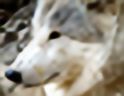

In [25]:
print("31px -> 124px")
inp = transform(Image.open(X64_valid_paths[4])).to(device)
with torch.inference_mode():
    out = (((model(inp[None])+1.0)/2.0).clamp(0.0, 1.0) * 255.0).squeeze()

img = Image.fromarray(out.permute(1, 2, 0).to(torch.uint8).cpu().numpy())
os.makedirs('../image_results/4X/31px', exist_ok=True)
img.save('../image_results/4X/31px/SRResNet_31px.png')
img

63px -> 252px


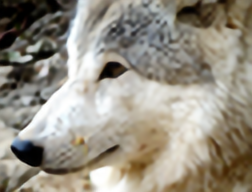

In [26]:
print("63px -> 252px")
inp = transform(Image.open(X32_valid_paths[4])).to(device)
with torch.inference_mode():
    out = (((model(inp[None])+1.0)/2.0).clamp(0.0, 1.0) * 255.0).squeeze()

img = Image.fromarray(out.permute(1, 2, 0).to(torch.uint8).cpu().numpy())
os.makedirs('../image_results/4X/63px', exist_ok=True)
img.save('../image_results/4X/63px/SRResNet_63px.png')
img

127px -> 508px


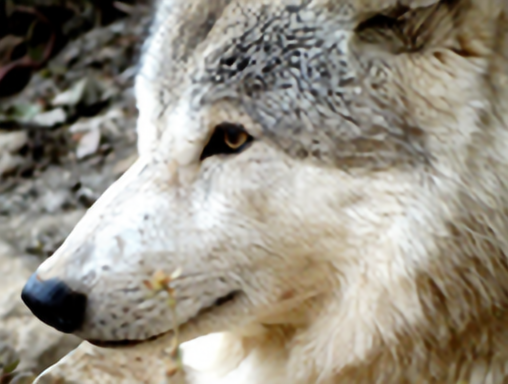

In [27]:
print("127px -> 508px")
inp = transform(Image.open(X16_valid_paths[4])).to(device)
with torch.inference_mode():
    out = (((model(inp[None])+1.0)/2.0).clamp(0.0, 1.0) * 255.0).squeeze()

img = Image.fromarray(out.permute(1, 2, 0).to(torch.uint8).cpu().numpy())
os.makedirs('../image_results/4X/127px', exist_ok=True)
img.save('../image_results/4X/127px/SRResNet_127px.png')
img

255px -> 1020px


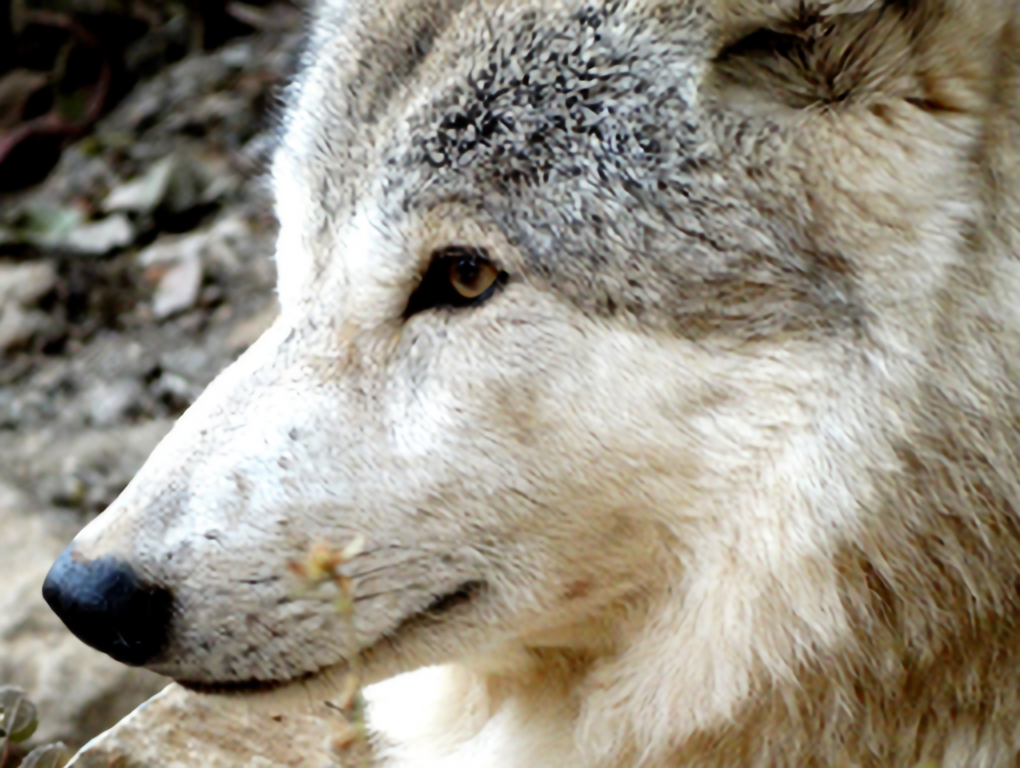

In [28]:
print("255px -> 1020px")
inp = transform(Image.open(X8_valid_paths[4])).to(device)
with torch.inference_mode():
    out = (((model(inp[None])+1.0)/2.0).clamp(0.0, 1.0) * 255.0).squeeze()

img = Image.fromarray(out.permute(1, 2, 0).to(torch.uint8).cpu().numpy())
os.makedirs('../image_results/4X/255px', exist_ok=True)
img.save('../image_results/4X/255px/SRResNet_255px.png')
img

510px -> 2040px


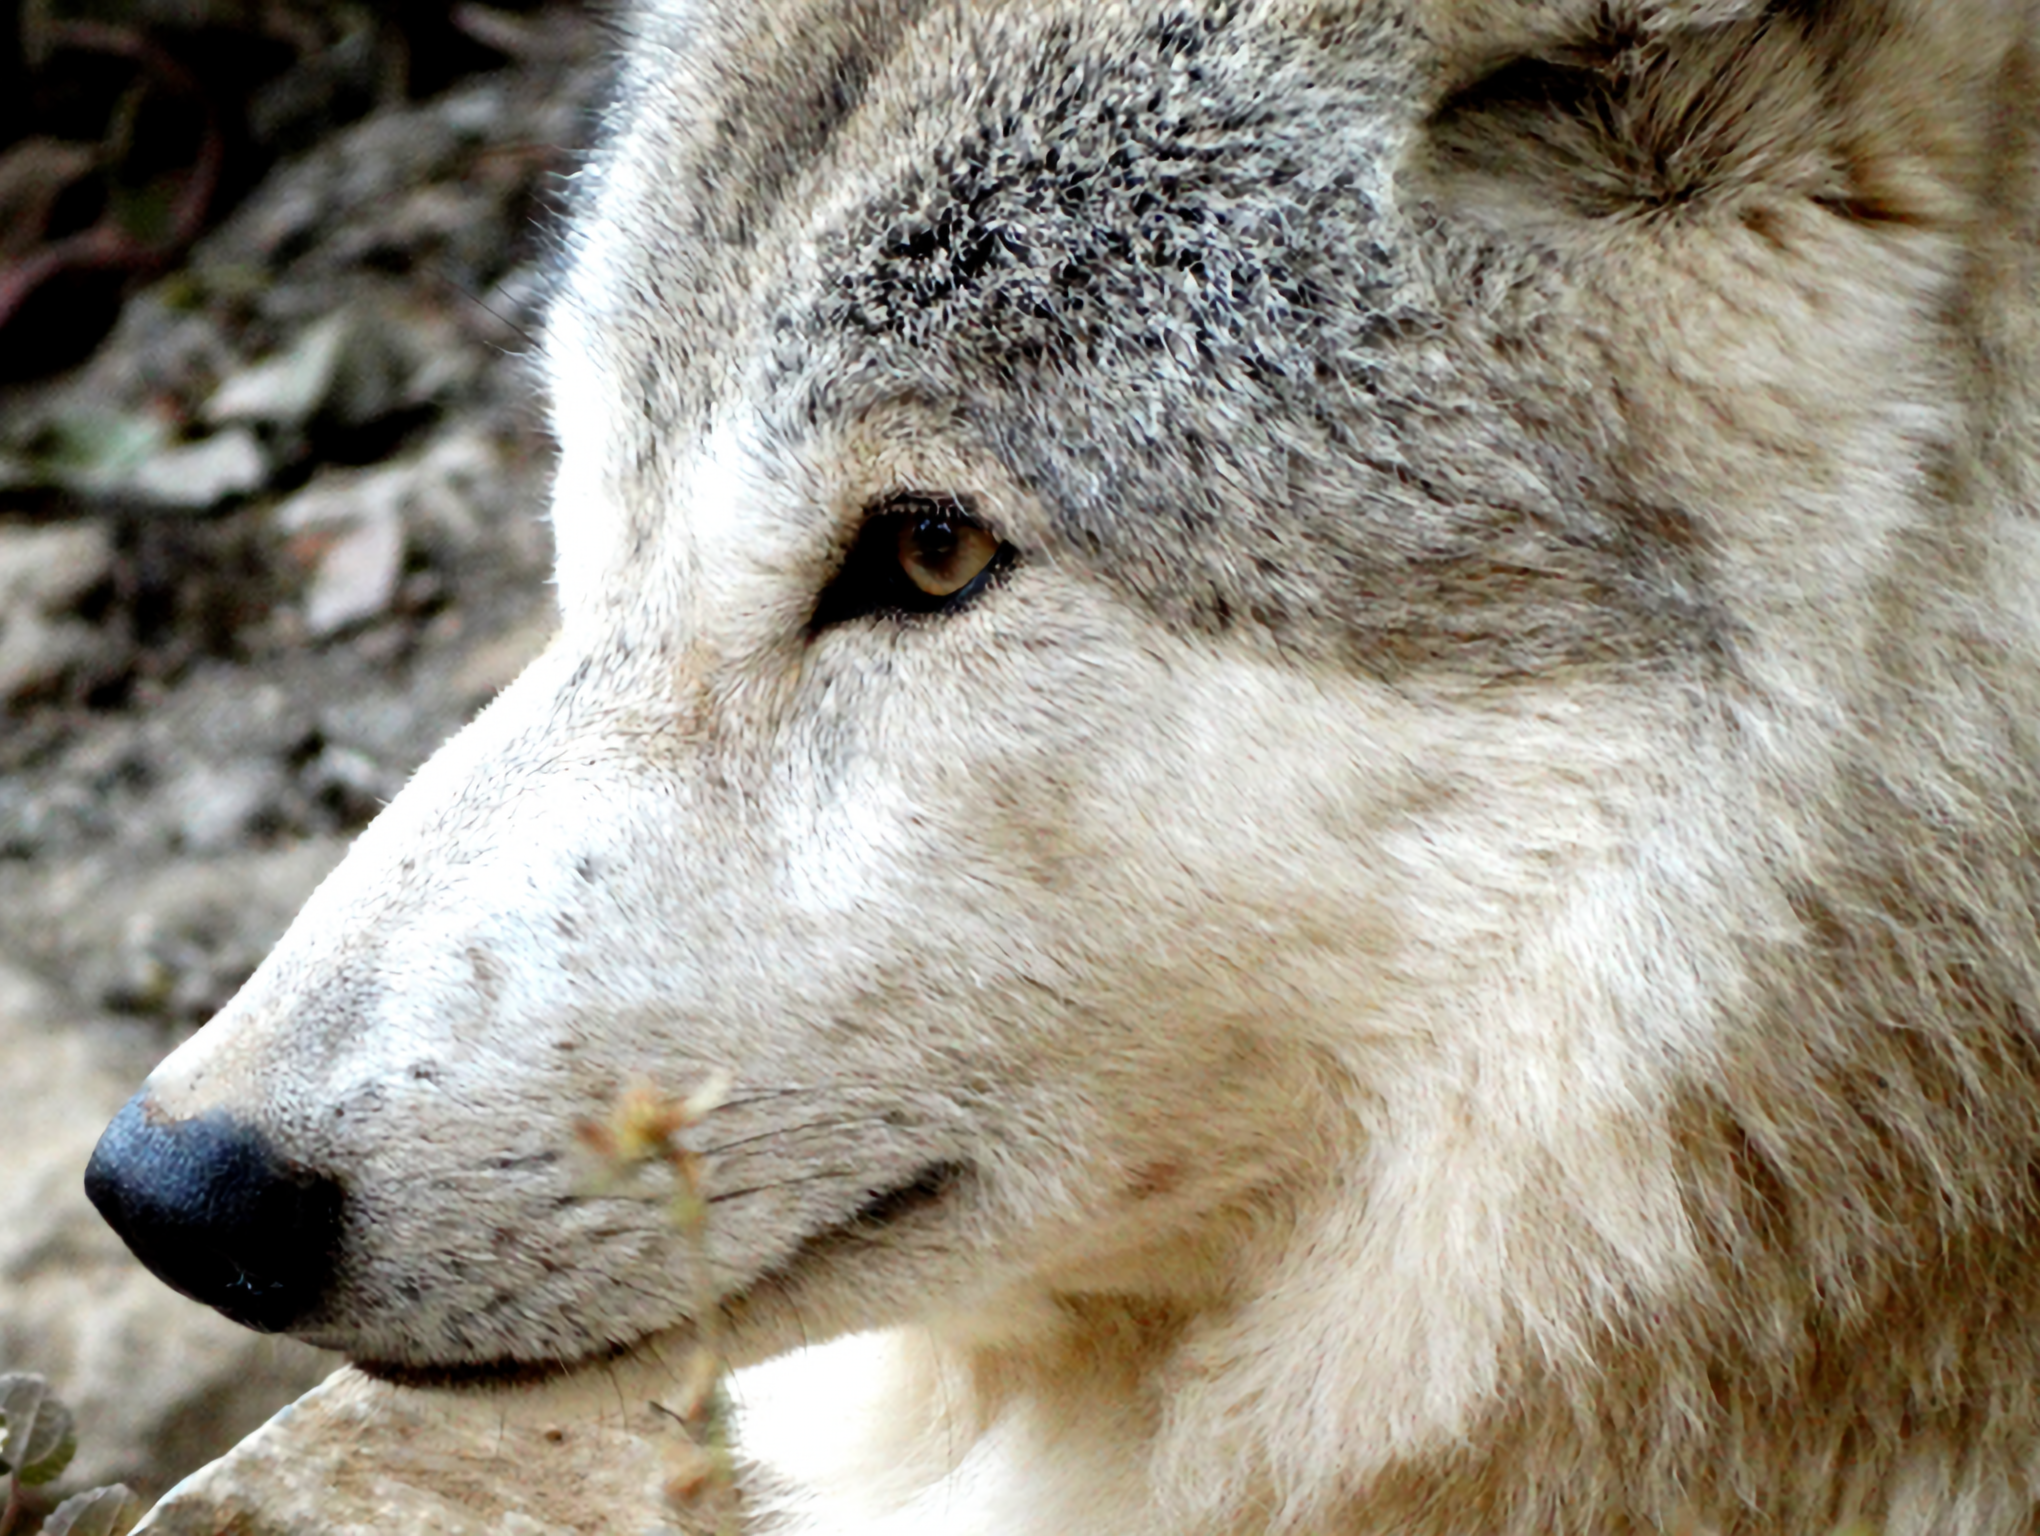

In [29]:
print("510px -> 2040px")
inp = transform(Image.open(X4_valid_paths[4])).to(device)
with torch.inference_mode():
    out = (((model(inp[None])+1.0)/2.0).clamp(0.0, 1.0) * 255.0).squeeze()

img = Image.fromarray(out.permute(1, 2, 0).to(torch.uint8).cpu().numpy())
os.makedirs('../image_results/4X/510px', exist_ok=True)
img.save('../image_results/4X/510px/SRResNet_510px.png')
img